# Causal-style fixed effects OLS (statsmodels)

This notebook estimates a quasi-experimental relationship between **temperature** and **log finish time** using **high-dimensional fixed effects**.

Core specification (approx.):

log(finish_time_{swimmer,event,day}) ~ α*temp_{pool,day} + β*temp^2_{pool,day} + δ_{swimmer,year} + ψ_{month,year} + φ_{event} + η_{meet} + e_{swimmer,event,day}


Notes:
- `finish_time` is `time_seconds` parsed from `time_str`.
- Temperature exposure uses race-time ERA5 hourly data when available (`results_with_race_time_weather.csv`).
- Fixed effects are implemented via categorical dummies (`C(...)`) in statsmodels.


In [14]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
import patsy


In [15]:
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "notebooks").exists() else Path.cwd().parent
PROCESSED = PROJECT_ROOT / "data" / "processed"

RACE_TIME_PATH = PROCESSED / "results_with_race_time_weather.csv"
MEET_AVG_PATH = PROCESSED / "results_with_environment.csv"

RACE_TIME_PATH, MEET_AVG_PATH

(PosixPath('/Users/huangrh/workspace/serena/swim-performance/data/processed/results_with_race_time_weather.csv'),
 PosixPath('/Users/huangrh/workspace/serena/swim-performance/data/processed/results_with_environment.csv'))

## 1) Load data

Prefer `results_with_race_time_weather.csv` (hourly exposure at race start). If it doesn't exist, fall back to meet-average exposure.

In [16]:
if RACE_TIME_PATH.exists():
    df = pd.read_csv(RACE_TIME_PATH)
    exposure_temp_col = "race_time_temperature"
    exposure_wbgt_col = "race_time_wbgt"
    print("Loaded:", RACE_TIME_PATH.name, df.shape)
else:
    df = pd.read_csv(MEET_AVG_PATH)
    exposure_temp_col = "temperature"
    exposure_wbgt_col = "wbgt"
    print("Loaded:", MEET_AVG_PATH.name, df.shape)
    print("WARNING: Using meet-average exposure (not race-time).")

required = [
    "meet_id",
    "person_id",
    "race_start_time",
    "discipline_name",
    "gender",
    "phase",
    "time_seconds",
    exposure_temp_col,
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df.head(3)

Loaded: results_with_race_time_weather.csv (4846, 34)


,meet_id,person_id,race_start_time,discipline_name,gender,phase,points,time_str,rank,athlete_name,...,relative_humidity,wbgt,city,country,race_time_temperature,race_time_dewpoint,race_time_wind_speed,race_time_pressure,race_time_relative_humidity,race_time_wbgt
0,oly_2008,93b926bc-5bb2-41a1-8116-68407f294686,2008-08-12T02:31:00,Men's 100m Backstroke,Men,Finals,1025.0,52.54,1.0,Aaron PEIRSOL,...,73.07979,25.211736,Beijing,China,21.734674,21.016321,0.700054,998.447188,95.701644,24.586829
1,oly_2008,18fbe8bb-dd04-4f33-a4af-533ff6a02f9c,2008-08-12T02:31:00,Men's 100m Backstroke,Men,Finals,992.0,53.11,2.0,Matt GREVERS,...,73.07979,25.211736,Beijing,China,21.734674,21.016321,0.700054,998.447188,95.701644,24.586829
2,oly_2008,e5312f2e-d574-440e-9bd1-026e8af0bf90,2008-08-12T02:31:00,Men's 100m Backstroke,Men,Finals,988.0,53.18,3.0,Arkady VYATCHANIN,...,73.07979,25.211736,Beijing,China,21.734674,21.016321,0.700054,998.447188,95.701644,24.586829


## 2) Build FE keys and analysis sample

- Restrict to **Finals**.
- Create:
  - `event_key = discipline_name + '_' + gender`
  - `year`, `month`
  - `swimmer_year = person_id × year`
  - `month_year = month × year`

These match the intent of absorbing baseline performance for swimmers (within year), seasonality, event identity, and meet-level factors.

In [17]:
df = df.copy()
df = df[df["phase"].astype(str) == "Finals"].copy()

df["race_dt"] = pd.to_datetime(df["race_start_time"], errors="coerce")
df = df[df["race_dt"].notna()].copy()

df["year"] = df["race_dt"].dt.year.astype(int)
df["month"] = df["race_dt"].dt.month.astype(int)
df["day"] = df["race_dt"].dt.date

df["event_key"] = df["discipline_name"].astype(str) + "_" + df["gender"].astype(str)
df["swimmer_year"] = df["person_id"].astype(str) + "_" + df["year"].astype(str)
df["month_year"] = df["month"].astype(str) + "_" + df["year"].astype(str)

df["temp"] = pd.to_numeric(df[exposure_temp_col], errors="coerce")
df["temp2"] = df["temp"] ** 2
df["time_seconds"] = pd.to_numeric(df["time_seconds"], errors="coerce")
df = df[(df["temp"].notna()) & (df["time_seconds"].notna()) & (df["time_seconds"] > 0)].copy()

df["log_time"] = np.log(df["time_seconds"].astype(float))

# Center temperature (helps temp vs temp^2 collinearity; intercept becomes effect at mean temp)
temp_mu = float(df["temp"].mean())
df["temp_c"] = df["temp"] - temp_mu
df["temp_c2"] = df["temp_c"] ** 2
print(f"Centered temperature at mean = {temp_mu:.2f}°C")

print("Rows (Finals, valid time, valid temp):", len(df))
display(df[["meet_id", "person_id", "race_start_time", "event_key", "time_seconds", "temp", "temp_c"]].head())

Centered temperature at mean = 25.14°C
Rows (Finals, valid time, valid temp): 2900


,meet_id,person_id,race_start_time,event_key,time_seconds,temp,temp_c
0,oly_2008,93b926bc-5bb2-41a1-8116-68407f294686,2008-08-12T02:31:00,Men's 100m Backstroke_Men,52.54,21.734674,-3.403632
1,oly_2008,18fbe8bb-dd04-4f33-a4af-533ff6a02f9c,2008-08-12T02:31:00,Men's 100m Backstroke_Men,53.11,21.734674,-3.403632
2,oly_2008,e5312f2e-d574-440e-9bd1-026e8af0bf90,2008-08-12T02:31:00,Men's 100m Backstroke_Men,53.18,21.734674,-3.403632
3,oly_2008,a42aa3f5-7f2c-4cba-938b-031b06b5c4d4,2008-08-12T02:31:00,Men's 100m Backstroke_Men,53.18,21.734674,-3.403632
4,oly_2008,91dd7ae2-4c45-4975-8f79-dc808ddf3fd1,2008-08-12T02:31:00,Men's 100m Backstroke_Men,53.31,21.734674,-3.403632


In [18]:
# Sanity checks for identification / FE sizes
fe_cols = ["swimmer_year", "month_year", "event_key", "meet_id"]
for c in fe_cols:
    print(f"{c}: {df[c].nunique()} levels")

print("\nWithin-meet temperature variation (std of temp within meet):")
within_meet_std = df.groupby("meet_id")["temp"].std().dropna()
print(within_meet_std.describe())


swimmer_year: 1492 levels
month_year: 14 levels
event_key: 42 levels
meet_id: 10 levels

Within-meet temperature variation (std of temp within meet):
count    10.000000
mean      1.663547
std       1.068949
min       0.474297
25%       0.895120
50%       1.168508
75%       2.463621
max       3.502198
Name: temp, dtype: float64


## Temperature exploration

Distribution of race-time temperature and variation across meets.


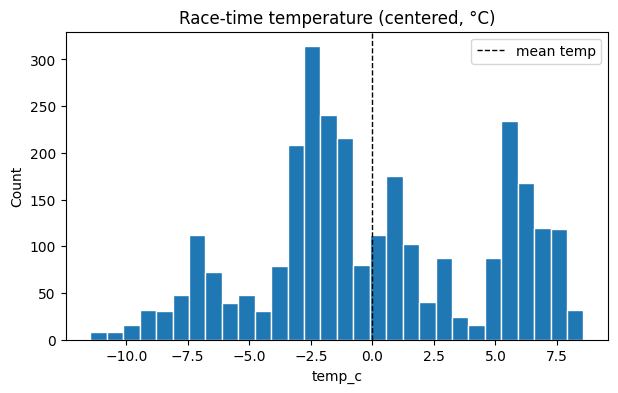

,min,max,mean,std
meet_id,,,,
oly_2012,-11.460395,-5.252845,-7.777238,1.368437
oly_2008,-7.996040,-0.641395,-3.226357,2.022609
wc_2024,-5.952796,4.057763,-2.243212,2.610625
oly_2020,-3.208564,-1.507911,-2.201417,0.474297
oly_2024,-7.274024,6.656609,-0.856417,3.502198
wc_1994,-1.838294,1.396325,0.143061,0.968578
wc_1991,-2.860847,6.735925,2.132245,3.078072
wc_2003,2.639855,5.581933,4.369954,0.897455
wc_2009,4.830834,7.776391,5.948930,0.818857


In [19]:
# Temperature distribution (centered)
plt.figure(figsize=(7, 4))
plt.hist(df["temp_c"], bins=30, edgecolor="white")
plt.axvline(0, color="k", linestyle="--", linewidth=1, label="mean temp")
plt.title("Race-time temperature (centered, °C)")
plt.xlabel("temp_c")
plt.ylabel("Count")
plt.legend()
plt.show()

# Temperature by meet
temp_by_meet = df.groupby("meet_id")["temp_c"].agg(["min", "max", "mean", "std"])
temp_by_meet = temp_by_meet.sort_values("mean")
temp_by_meet


## 3) Main model: log(time) on temp + temp² + fixed effects

We estimate the same FE specification, but use **Frisch–Waugh / FE absorption** instead of ~1,500 explicit swimmer-year dummies. That is numerically stable and equivalent in theory.

**Normalization used here**
- Outcome: `log_time = log(time_seconds)` (percent-like effects across events)
- Exposure: `temp_c = temp - mean(temp)` and `temp_c2 = temp_c²` (reduces collinearity between linear and quadratic terms)

**Do not interpret swimmer-year dummy coefficients from the old approach** — with explicit dummies, intercepts can blow up to `1e8`+ when FEs are nearly collinear. After absorption we only report **temp** coefficients.

### What identifies α, β?
With `meet_id` fixed effects absorbed, identification comes from **within-meet** temperature variation across race times/days. `swimmer_year` absorbs each swimmer’s baseline in that year; `event_key` absorbs event difficulty.

In [20]:
# Exposure (centered) and fixed-effect dimensions to absorb
exposure_cols = ["temp_c", "temp_c2"]
fe_cols_full = ["swimmer_year", "month_year", "event_key", "meet_id"]
exposure_cols, fe_cols_full

(['temp_c', 'temp_c2'], ['swimmer_year', 'month_year', 'event_key', 'meet_id'])

In [21]:
# How much temperature variance remains after FE absorption?
# Compare temp_c.std() (raw, centered) vs temp_resid.std() after residualizing on FEs.
import patsy


def _residualize_vec_diag(y, Z):
    coef, _, _, _ = np.linalg.lstsq(Z, y, rcond=None)
    return y - Z @ coef


def temp_absorption_summary(data, fe_list, label):
    cols = ["temp_c"] + list(fe_list)
    d = data.dropna(subset=cols).copy()
    temp_raw = d["temp_c"].to_numpy(dtype=float)
    raw_std = float(np.std(temp_raw, ddof=1))

    if not fe_list:
        temp_resid = temp_raw
    else:
        fe_formula = "0 + " + " + ".join(f"C({c})" for c in fe_list)
        Z = patsy.dmatrix(fe_formula, data=d, return_type="dataframe").to_numpy(dtype=float)
        temp_resid = _residualize_vec_diag(temp_raw, Z)

    resid_std = float(np.std(temp_resid, ddof=1))
    pct_var = 100 * (resid_std ** 2) / (raw_std ** 2) if raw_std > 0 else np.nan
    return {
        "Model / FE spec": label,
        "temp_c.std()": raw_std,
        "temp_resid.std()": resid_std,
        "% variance retained": pct_var,
    }


fe_specs = [
    ("Model 0: none", []),
    ("Model 1: + event", ["event_key"]),
    ("Model 2: + swimmer_year", ["event_key", "swimmer_year"]),
    ("Model 3: + month_year", ["event_key", "swimmer_year", "month_year"]),
    ("Model 4: + meet", ["event_key", "swimmer_year", "month_year", "meet_id"]),
]

temp_var_rows = [temp_absorption_summary(df, fe, label) for label, fe in fe_specs]
temp_var_table = pd.DataFrame(temp_var_rows)
temp_var_table


,Model / FE spec,temp_c.std(),temp_resid.std(),% variance retained
0,Model 0: none,4.611854,4.611854,100.000000
1,Model 1: + event,4.611854,4.439440,92.662803
2,Model 2: + swimmer_year,4.508049,1.216931,7.287103
3,Model 3: + month_year,4.508049,1.148970,6.495911
4,Model 4: + meet,4.508049,1.148970,6.495911


In [22]:
# FE absorption (Frisch-Waugh): residualize y and exposure w.r.t. all fixed effects,
# then OLS on residuals. Avoids estimating ~1,500 swimmer-year intercepts explicitly.
import statsmodels.api as sm
import patsy


def _residualize_vec(y, Z):
    coef, _, _, _ = np.linalg.lstsq(Z, y, rcond=None)
    return y - Z @ coef


def absorb_and_fit(data, y_col, x_cols, fe_cols, cluster_col="meet_id"):
    need = [y_col, cluster_col] + list(x_cols) + list(fe_cols)
    d = data.dropna(subset=need).copy()

    y = d[y_col].to_numpy(dtype=float)
    fe_formula = "0 + " + " + ".join(f"C({c})" for c in fe_cols)
    Z = patsy.dmatrix(fe_formula, data=d, return_type="dataframe").to_numpy(dtype=float)

    y_res = _residualize_vec(y, Z)
    X_res = {col: _residualize_vec(d[col].to_numpy(dtype=float), Z) for col in x_cols}
    X_df = pd.DataFrame(X_res, index=d.index)
    y_s = pd.Series(y_res, index=d.index, name="y_res")

    base = sm.OLS(y_s, X_df, hasconst=False).fit(method="qr")
    return base.get_robustcov_results(cov_type="cluster", groups=d[cluster_col])


def joint_exposure_f_test(res, terms):
    """H0: all listed exposure coefficients are zero (joint Wald / F-test)."""
    names = list(res.model.exog_names)
    k = len(names)
    R = np.zeros((len(terms), k))
    for i, term in enumerate(terms):
        R[i, names.index(term)] = 1.0
    ft = res.f_test(R)
    return float(ft.fvalue), float(ft.pvalue)


def _results_to_table(res, cols):
    """Per-coefficient t-tests: coef, std err, 95% CI, p-value."""
    names = list(res.model.exog_names)
    params = np.asarray(res.params).ravel()
    bse = np.asarray(res.bse).ravel()
    pvals = np.asarray(res.pvalues).ravel()
    ci = np.asarray(res.conf_int(alpha=0.05))
    tab = pd.DataFrame({
        "coef": params,
        "std err": bse,
        "CI lower": ci[:, 0],
        "CI upper": ci[:, 1],
        "p-value (t-test)": pvals,
    }, index=names)
    return tab.loc[cols]


def print_exposure_summary(res, cols):
    display(_results_to_table(res, cols))
    f_stat, f_p = joint_exposure_f_test(res, cols)
    print(f"Joint test H0: all exposure terms = 0  |  F = {f_stat:.4f}, p = {f_p:.4f}")


def fit_model(data, fe_cols, x_cols=("temp", "temp2"), cluster_col="meet_id"):
    """OLS of log_time on temp + temp2, optionally absorbing fe_cols (cluster SEs)."""
    need = ["log_time", cluster_col] + list(x_cols) + list(fe_cols)
    d = data.dropna(subset=need).copy()
    if not fe_cols:
        X = sm.add_constant(d[list(x_cols)])
        base = sm.OLS(d["log_time"], X).fit(method="qr")
        return base.get_robustcov_results(cov_type="cluster", groups=d[cluster_col])
    return absorb_and_fit(d, "log_time", list(x_cols), fe_cols, cluster_col)


def _term_row(res, term, prefix):
    names = list(res.model.exog_names)
    i = names.index(term)
    params = np.asarray(res.params).ravel()
    bse = np.asarray(res.bse).ravel()
    pvals = np.asarray(res.pvalues).ravel()
    ci = np.asarray(res.conf_int(alpha=0.05))
    return {
        f"{prefix} coef": params[i],
        f"{prefix} std err": bse[i],
        f"{prefix} CI lower": ci[i, 0],
        f"{prefix} CI upper": ci[i, 1],
        f"{prefix} p-value (t)": pvals[i],
    }


fe_cols_used = fe_cols_full
try:
    res_meet = absorb_and_fit(df, "log_time", exposure_cols, fe_cols_used)
    print("Absorbed FE:", fe_cols_used)
except np.linalg.LinAlgError as e:
    print("Primary fit failed:", type(e).__name__, str(e))
    fe_cols_used = [c for c in fe_cols_full if c != "month_year"]
    print("Retrying without month_year; absorbed FE:", fe_cols_used)
    res_meet = absorb_and_fit(df, "log_time", exposure_cols, fe_cols_used)

print("\nExposure coefficients (after absorbing fixed effects):")
print("Per-coefficient p-values are t-tests; see joint F-test below the table.")
print_exposure_summary(res_meet, exposure_cols)


Absorbed FE: ['swimmer_year', 'month_year', 'event_key', 'meet_id']

Exposure coefficients (after absorbing fixed effects):
Per-coefficient p-values are t-tests; see joint F-test below the table.


,coef,std err,CI lower,CI upper,p-value (t-test)
temp_c,0.000007,0.000157,-0.000349,0.000363,0.964751
temp_c2,-0.000022,0.000022,-0.000072,0.000028,0.345613


Joint test H0: all exposure terms = 0  |  F = 1.7174, p = 0.2335


## Sequential model ladder (Models 0–4)

Cumulative fixed effects on `log_time ~ temp + temp²` (cluster-robust SEs by meet). Each row adds one FE layer; earlier layers are retained.

**Inference notes**
- `p-value (t)` columns: **individual** t-tests (H₀: that coefficient = 0), holding the other exposure term fixed.
- `Joint F p-value`: **joint** test H₀: α = β = 0 (both temp and temp² zero together). This is often the more informative summary for a quadratic exposure spec.


In [23]:
model_specs = [
    ("Model 0: temp + temp²", []),
    ("Model 1: + event FE", ["event_key"]),
    ("Model 2: + swimmer_year FE", ["event_key", "swimmer_year"]),
    ("Model 3: + month_year FE", ["event_key", "swimmer_year", "month_year"]),
    ("Model 4: + meet FE", ["event_key", "swimmer_year", "month_year", "meet_id"]),
]

exposure_terms = ("temp", "temp2")

rows = []
for label, fe in model_specs:
    res = fit_model(df, fe)
    row = {"Model": label}
    row.update(_term_row(res, "temp", "Temp"))
    row.update(_term_row(res, "temp2", "Temp²"))
    f_stat, f_p = joint_exposure_f_test(res, exposure_terms)
    row["Joint F stat"] = f_stat
    row["Joint F p-value"] = f_p
    rows.append(row)

model_ladder = pd.DataFrame(rows)

model_ladder_display = model_ladder.copy()
for col in model_ladder_display.columns:
    if col == "Model":
        continue
    if "p-value" in col or col == "Joint F stat":
        model_ladder_display[col] = model_ladder_display[col].map(lambda x: f"{x:.4f}")
    else:
        model_ladder_display[col] = model_ladder_display[col].map(lambda x: f"{x:.6f}")

model_ladder_display


,Model,Temp coef,Temp std err,Temp CI lower,Temp CI upper,Temp p-value (t),Temp² coef,Temp² std err,Temp² CI lower,Temp² CI upper,Temp² p-value (t),Joint F stat,Joint F p-value
0,Model 0: temp + temp²,-0.002341,0.093651,-0.214195,0.209513,0.9806,-0.000130,0.001821,-0.004250,0.003990,0.9447,0.9573,0.4198
1,Model 1: + event FE,0.012266,0.011114,-0.012875,0.037408,0.2984,-0.000234,0.000221,-0.000733,0.000265,0.3168,1.0048,0.4037
2,Model 2: + swimmer_year FE,0.000845,0.001054,-0.001539,0.003230,0.4432,-0.000020,0.000021,-0.000068,0.000028,0.3651,1.4884,0.2764
3,Model 3: + month_year FE,0.001119,0.000991,-0.001122,0.003361,0.2878,-0.000022,0.000022,-0.000072,0.000028,0.3456,1.7174,0.2335
4,Model 4: + meet FE,0.001119,0.000991,-0.001122,0.003361,0.2878,-0.000022,0.000022,-0.000072,0.000028,0.3456,1.7174,0.2335


## 4) Interpret \(\alpha\) and \(\beta\)

With a quadratic, the marginal effect on log time at temperature \(t\) is:

\[
\frac{\partial\,\log(time)}{\partial t} = \alpha + 2\beta t
\]

The turning point (minimum/maximum) is \(-\alpha/(2\beta)\) when \(\beta \neq 0\).

In [24]:
_names = list(res_meet.model.exog_names)
_p = dict(zip(_names, np.asarray(res_meet.params).ravel()))

alpha = _p.get("temp_c", np.nan)
beta = _p.get("temp_c2", np.nan)

print("alpha (temp_c):", alpha)
print("beta (temp_c2):", beta)
print(f"(temp centered at mean = {temp_mu:.2f}°C)")

temps = [18.0, 24.0, 30.0]
for t in temps:
    # d log(time)/d temp in raw °C when temp_c = temp - temp_mu
    dlogdt = alpha + 2 * beta * (t - temp_mu)
    print(f"d log(time) / d temp at {t:.1f}°C: {dlogdt:.6f}  (~{100*dlogdt:.3f}% per +1°C)")

if np.isfinite(alpha) and np.isfinite(beta) and beta != 0:
    turning = temp_mu - alpha / (2 * beta)
    print("Turning point (°C):", turning)


alpha (temp_c): 7.149753855588237e-06
beta (temp_c2): -2.2121541897014112e-05
(temp centered at mean = 25.14°C)
d log(time) / d temp at 18.0°C: 0.000323  (~0.032% per +1°C)
d log(time) / d temp at 24.0°C: 0.000058  (~0.006% per +1°C)
d log(time) / d temp at 30.0°C: -0.000208  (~-0.021% per +1°C)
Turning point (°C): 25.299907985522736


## 5) Partial effect curve (holding FE constant)

This plots the fitted quadratic component relative to a reference temperature \(t_0\). It’s a convenient visualization of the implied log-time changes from temperature alone.

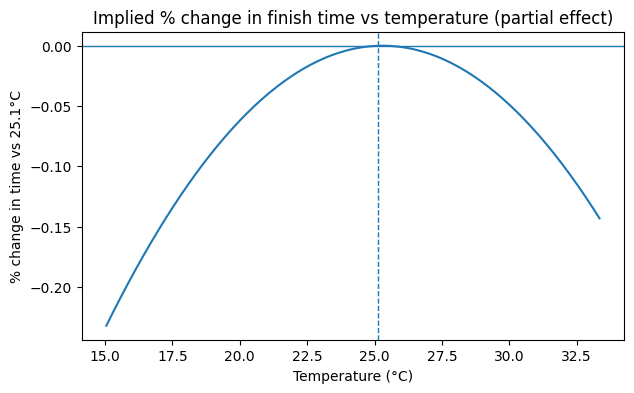

In [25]:
t_min, t_max = float(np.nanpercentile(df["temp"], 1)), float(np.nanpercentile(df["temp"], 99))
t_grid = np.linspace(t_min, t_max, 200)
t0 = temp_mu

# Partial quadratic effect relative to mean temperature (temp_c = 0 at t0)
delta_log = alpha * (t_grid - t0) + beta * ((t_grid - t0) ** 2)
delta_pct = 100 * (np.exp(delta_log) - 1)

plt.figure(figsize=(7, 4))
plt.plot(t_grid, delta_pct)
plt.axhline(0, linewidth=1)
plt.axvline(t0, linestyle="--", linewidth=1)
plt.title("Implied % change in finish time vs temperature (partial effect)")
plt.xlabel("Temperature (°C)")
plt.ylabel(f"% change in time vs {t0:.1f}°C")
plt.show()

## 6) Robustness: alternative clustering (by swimmer)

Weather shocks are naturally correlated within meets, but it can also be informative to see how inference changes when clustering by swimmer.


In [26]:
# Alternative clustering by swimmer (person_id)
res_swimmer = absorb_and_fit(df, "log_time", exposure_cols, fe_cols_used, cluster_col="person_id")
print("Exposure coefficients (clustered by person_id):")
print_exposure_summary(res_swimmer, exposure_cols)

Exposure coefficients (clustered by person_id):


,coef,std err,CI lower,CI upper,p-value (t-test)
temp_c,0.000007,0.000155,-0.000296,0.000311,0.963142
temp_c2,-0.000022,0.000020,-0.000062,0.000018,0.275497


Joint test H0: all exposure terms = 0  |  F = 0.6080, p = 0.5446


## 7) Robustness: WBGT exposure (quadratic)

If WBGT is available, re-estimate the same model with WBGT and WBGT² instead of temperature.


In [27]:
if exposure_wbgt_col in df.columns:
    df_w = df.copy()
    df_w["wbgt"] = pd.to_numeric(df_w[exposure_wbgt_col], errors="coerce")
    df_w = df_w[df_w["wbgt"].notna()].copy()

    if len(df_w) < 200:
        print("Too few rows with WBGT available:", len(df_w))
    else:
        wbgt_mu = float(df_w["wbgt"].mean())
        df_w["wbgt_c"] = df_w["wbgt"] - wbgt_mu
        df_w["wbgt_c2"] = df_w["wbgt_c"] ** 2
        exposure_wbgt = ["wbgt_c", "wbgt_c2"]
        print(f"Centered WBGT at mean = {wbgt_mu:.2f}°C")
        r_w = absorb_and_fit(df_w, "log_time", exposure_wbgt, fe_cols_used)
        print("Exposure coefficients (WBGT, after absorbing fixed effects):")
        print_exposure_summary(r_w, exposure_wbgt)
else:
    print("WBGT column not found:", exposure_wbgt_col)

Centered WBGT at mean = 24.84°C
Exposure coefficients (WBGT, after absorbing fixed effects):


,coef,std err,CI lower,CI upper,p-value (t-test)
wbgt_c,0.000213,0.000145,-0.000115,0.000542,0.175823
wbgt_c2,0.000013,0.000037,-0.000069,0.000096,0.723546


Joint test H0: all exposure terms = 0  |  F = 1.4552, p = 0.2834
